In [2]:
import pandas as pd
import glob
import gzip
import os

def leer_archivo_rcc(ruta_archivo):
    """Lee un archivo .RCC o .RCC.gz y extrae la sección de conteos (Code_Summary)"""
    
    # Abrir con gzip si está comprimido, o apertura normal si lo descomprimiste
    abrir_archivo = gzip.open if ruta_archivo.endswith('.gz') else open
    
    datos = []
    leyendo_conteos = False
    
    with abrir_archivo(ruta_archivo, 'rt', encoding='utf-8') as f:
        for linea in f:
            linea = linea.strip()
            
            # Detectar dónde empiezan y terminan los datos
            if linea == '<Code_Summary>':
                leyendo_conteos = True
                continue
            elif linea == '</Code_Summary>':
                break
                
            # Guardar las líneas si estamos dentro de la sección correcta
            if leyendo_conteos:
                # Los RCC suelen estar separados por comas
                datos.append(linea.split(','))
                
    # Convertir a DataFrame
    # La primera fila guardada tiene los nombres de las columnas (CodeClass, Name, Accession, Count)
    columnas = datos[0]
    df = pd.DataFrame(datos[1:], columns=columnas)
    
    # Convertir la columna de conteos a números enteros
    if 'Count' in df.columns:
        df['Count'] = pd.to_numeric(df['Count'])
        
    return df

# --- Cómo usarlo para procesar todos los archivos ---

# 1. Pone la ruta a la carpeta donde tenés los .RCC.gz
carpeta_rcc = r'C:\Users\fran_\Documents\Doctorado\Inicios\Dani\GSE255271\GSE255271_RAW' # Cambiá esto por la ruta de tu carpeta
archivos_rcc = glob.glob(os.path.join(carpeta_rcc, '*.RCC.gz'))

print(f"Se encontraron {len(archivos_rcc)} archivos.")

# 2. Leer el primero de prueba para ver cómo queda
if archivos_rcc:
    archivo_prueba = archivos_rcc[0]
    print(f"\nLeyendo: {os.path.basename(archivo_prueba)}")
    df_prueba = leer_archivo_rcc(archivo_prueba)
    
    print("\nPrimeros 5 genes:")
    print(df_prueba.head())
else:
    print("No se encontraron archivos .RCC.gz en la carpeta indicada.")

Se encontraron 12 archivos.

Leyendo: GSM8068020_20210608_30102603060422-01_CAT1624_02.RCC.gz

Primeros 5 genes:
    CodeClass    Name    Accession  Count
0  Endogenous  GLYCTK  NR_026700.1    125
1  Endogenous   RPLP0  NM_001002.3  12188
2  Endogenous    FLT3  NM_004119.2      3
3  Endogenous  SLC2A5  NM_003039.2      9
4  Endogenous  XCL1/2  NM_003175.3     10


In [4]:
import pandas as pd
import glob
import gzip
import os

carpeta_rcc = r'C:\Users\fran_\Documents\Doctorado\Inicios\Dani\GSE255271\GSE255271_RAW'
archivos_rcc = glob.glob(os.path.join(carpeta_rcc, '*.RCC*'))

def extraer_columna_conteos(ruta_archivo):
    abrir = gzip.open if ruta_archivo.endswith('.gz') else open
    datos = []
    leyendo = False
    
    with abrir(ruta_archivo, 'rt', encoding='utf-8') as f:
        for linea in f:
            linea = linea.strip()
            if linea == '<Code_Summary>': leyendo = True; continue
            if linea == '</Code_Summary>': break
            if leyendo: datos.append(linea.split(','))
            
    df = pd.DataFrame(datos[1:], columns=datos[0])
    df['Count'] = pd.to_numeric(df['Count'])
    
    nombre_archivo = os.path.basename(ruta_archivo)
    id_muestra = nombre_archivo.split('_')[0]
    
    df = df[['CodeClass', 'Name', 'Accession', 'Count']]
    df = df.rename(columns={'Count': id_muestra})
    return df

matriz_expresion = pd.DataFrame()
archivos_procesados = 0

print(f"Encontrados {len(archivos_rcc)} archivos. Procesando...\n")

for archivo in archivos_rcc:
    # Chequeo de seguridad: asegurar que es un archivo y no una carpeta
    if not os.path.isfile(archivo):
        continue
        
    try:
        df_muestra = extraer_columna_conteos(archivo)
        
        if matriz_expresion.empty:
            matriz_expresion = df_muestra
        else:
            matriz_expresion = pd.merge(matriz_expresion, df_muestra, on=['CodeClass', 'Name', 'Accession'], how='outer')
            
        archivos_procesados += 1
        
    except PermissionError:
        print(f"⚠️ Error de permisos: No se pudo leer el archivo (está bloqueado): {os.path.basename(archivo)}")
    except Exception as e:
        print(f"⚠️ Ocurrió otro error con {os.path.basename(archivo)}: {e}")

if not matriz_expresion.empty:
    archivo_salida = os.path.join(carpeta_rcc, 'Matriz_Conteos_NanoString_Completa.csv')
    matriz_expresion.to_csv(archivo_salida, index=False)
    print(f"\n¡Listo! Se fusionaron exitosamente {archivos_procesados} archivos.")
    print(f"Matriz guardada en: {archivo_salida}")
    print("\nPrimeras 5 filas:")
    print(matriz_expresion.head())
else:
    print("\nNo se pudo armar la matriz. Revisá los errores de arriba.")

Encontrados 13 archivos. Procesando...


¡Listo! Se fusionaron exitosamente 12 archivos.
Matriz guardada en: C:\Users\fran_\Documents\Doctorado\Inicios\Dani\GSE255271\GSE255271_RAW\Matriz_Conteos_NanoString_Completa.csv

Primeras 5 filas:
    CodeClass   Name    Accession  GSM8068020  GSM8068021  GSM8068022  \
0  Endogenous    A2M  NM_000014.4          18          10           7   
1  Endogenous  AADAT  NM_016228.3           2           2           4   
2  Endogenous  AANAT  NM_001088.2           3           0           5   
3  Endogenous   ABL1  NM_005157.3         211         169         221   
4  Endogenous  ACAA2  NM_006111.2         470         359         494   

   GSM8068023  GSM8068024  GSM8068025  GSM8068026  GSM8068027  GSM8068028  \
0          16          13          12          11           9          14   
1           7           8           6           5           5           2   
2           5           4           3           3           1           5   
3         208 

In [7]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import euclidean
from scipy.stats import zscore

# 1. Cargar matriz original
archivo = 'Matriz_Conteos_NanoString_Completa.csv'
df = pd.read_csv(archivo)

# 2. Renombrar las muestras
nombres_muestras = {
    'GSM8068020': 'CAT1624', 'GSM8068021': 'CAT1642', 'GSM8068022': 'CAT1643',
    'GSM8068023': 'CAT1645', 'GSM8068024': 'CAT1646', 'GSM8068025': 'CAT1647',
    'GSM8068026': 'CRF072', 'GSM8068027': 'CRF381', 'GSM8068028': 'CRF433',
    'GSM8068029': 'CRF468', 'GSM8068030': 'CRF509', 'GSM8068031': 'CRF518'
}
df.rename(columns=nombres_muestras, inplace=True)

# 3. Filtrar genes endógenos y preparar la tabla
df_endo = df[df['CodeClass'] == 'Endogenous'].copy()
df_endo.set_index('Name', inplace=True)
df_conteos = df_endo.drop(columns=['CodeClass', 'Accession'])

# 4. NORMALIZACIÓN BÁSICA (Z-score sobre Log2) - CORREGIDA
df_log = np.log2(df_conteos + 1)

# Calculamos el zscore manteniendo la estructura de tabla
valores_z = zscore(df_log, axis=1)
df_zscore = pd.DataFrame(valores_z, index=df_log.index, columns=df_log.columns)

# 5. DEFINIR PANELES DE GENES PARA LOS PERFILES
perfiles = {
    'Glucolítico': ['HK1', 'HK2', 'PFKP', 'ALDOA', 'GAPDH', 'PGK1', 'ENO1', 'PKM', 'LDHA', 'HIF1A'],
    'Lipídico': ['CPT1A', 'ACACA', 'FASN', 'SCD', 'CD36', 'FABP4', 'SREBF1', 'PPARG'],
    'Inflamatorio (M1)': ['TNF', 'IL6', 'IL1B', 'CXCL8', 'CCL2', 'STAT1', 'CD86', 'TLR4', 'NFKB1', 'NOS2'],
    'Tolerogénico (M2)': ['IL10', 'TGFB1', 'ARG1', 'CD163', 'MRC1', 'STAT3']
}

muestras_CAT = ['CAT1624', 'CAT1642', 'CAT1643', 'CAT1645', 'CAT1646', 'CAT1647']
muestras_CRF = ['CRF072', 'CRF381', 'CRF433', 'CRF468', 'CRF509', 'CRF518']

print("--- CONFIRMACIÓN DE PERFILES METABÓLICOS/INMUNES ---")
for nombre_perfil, lista_genes in perfiles.items():
    genes_presentes = [g for g in lista_genes if g in df_zscore.index]
    
    # Calculamos el promedio de Z-score de esos genes para cada paciente CAT
    scores = df_zscore.loc[genes_presentes, muestras_CAT].mean(axis=0).sort_values(ascending=False)
    
    print(f"\n> Perfil {nombre_perfil} (Basado en {len(genes_presentes)} genes)")
    print("Ranking:")
    for i, (muestra, score) in enumerate(scores.items(), 1):
        print(f"  {i}️⃣ {muestra} (Score: {score:.2f})")

# 6. DISTANCIA AL GRUPO CONTROL (CRF)
print("\n--- DISTANCIA AL GRUPO CONTROL (NO EMBARAZADAS) ---")
perfil_promedio_CRF = df_log[muestras_CRF].mean(axis=1)

distancias = {}
for cat in muestras_CAT:
    dist = euclidean(df_log[cat], perfil_promedio_CRF)
    distancias[cat] = dist

distancias_ordenadas = dict(sorted(distancias.items(), key=lambda item: item[1], reverse=True))

print("De más ALEJADA (Diferente) a más PARECIDA al grupo control:")
for i, (muestra, dist) in enumerate(distancias_ordenadas.items(), 1):
    if i <= 3:
        print(f"  🔴 {muestra} (Dist: {dist:.2f}) -> Más alejadas (Efecto fuerte)")
    elif i >= 5:
        print(f"  🟢 {muestra} (Dist: {dist:.2f}) -> Más parecidas a controles")
    else:
        print(f"  🟡 {muestra} (Dist: {dist:.2f}) -> Intermedia")

--- CONFIRMACIÓN DE PERFILES METABÓLICOS/INMUNES ---

> Perfil Glucolítico (Basado en 9 genes)
Ranking:
  1️⃣ CAT1643 (Score: 0.70)
  2️⃣ CAT1646 (Score: 0.64)
  3️⃣ CAT1645 (Score: 0.50)
  4️⃣ CAT1624 (Score: 0.17)
  5️⃣ CAT1647 (Score: -0.11)
  6️⃣ CAT1642 (Score: -0.43)

> Perfil Lipídico (Basado en 7 genes)
Ranking:
  1️⃣ CAT1645 (Score: 1.25)
  2️⃣ CAT1647 (Score: 0.67)
  3️⃣ CAT1646 (Score: 0.55)
  4️⃣ CAT1624 (Score: 0.49)
  5️⃣ CAT1643 (Score: 0.28)
  6️⃣ CAT1642 (Score: 0.26)

> Perfil Inflamatorio (M1) (Basado en 6 genes)
Ranking:
  1️⃣ CAT1642 (Score: 0.58)
  2️⃣ CAT1645 (Score: 0.55)
  3️⃣ CAT1646 (Score: 0.41)
  4️⃣ CAT1624 (Score: 0.28)
  5️⃣ CAT1643 (Score: 0.27)
  6️⃣ CAT1647 (Score: 0.23)

> Perfil Tolerogénico (M2) (Basado en 4 genes)
Ranking:
  1️⃣ CAT1643 (Score: 1.76)
  2️⃣ CAT1642 (Score: 0.20)
  3️⃣ CAT1624 (Score: 0.16)
  4️⃣ CAT1645 (Score: 0.15)
  5️⃣ CAT1646 (Score: -0.05)
  6️⃣ CAT1647 (Score: -0.08)

--- DISTANCIA AL GRUPO CONTROL (NO EMBARAZADAS) ---
De má

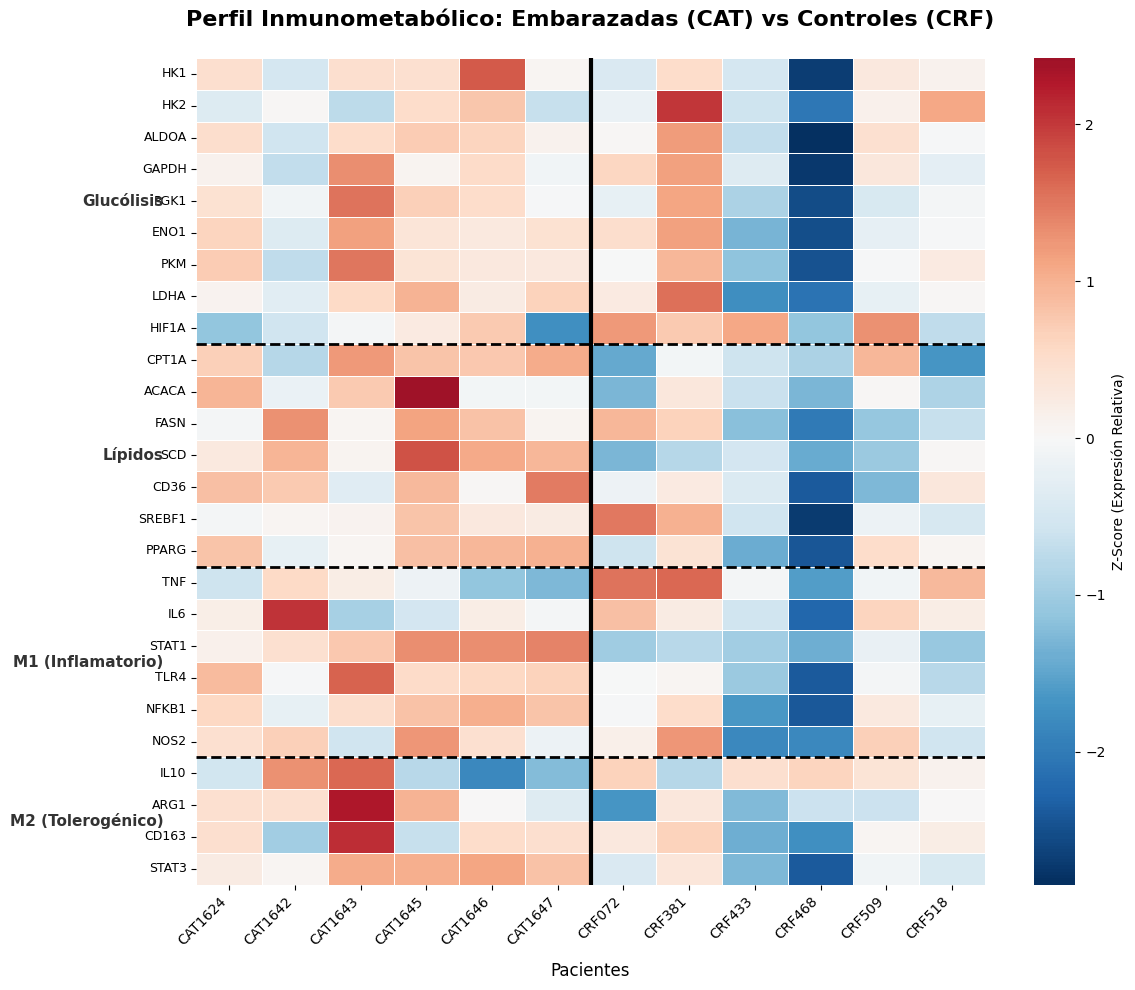


¡Gráfico generado con éxito! Se guardó como: 'Heatmap_Perfiles_Metabolicos.png' en tu carpeta.


In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

# 1. Cargar matriz y preparar datos (mismo paso de antes)
archivo = 'Matriz_Conteos_NanoString_Completa.csv'
df = pd.read_csv(archivo)

nombres_muestras = {
    'GSM8068020': 'CAT1624', 'GSM8068021': 'CAT1642', 'GSM8068022': 'CAT1643',
    'GSM8068023': 'CAT1645', 'GSM8068024': 'CAT1646', 'GSM8068025': 'CAT1647',
    'GSM8068026': 'CRF072', 'GSM8068027': 'CRF381', 'GSM8068028': 'CRF433',
    'GSM8068029': 'CRF468', 'GSM8068030': 'CRF509', 'GSM8068031': 'CRF518'
}
df.rename(columns=nombres_muestras, inplace=True)

df_endo = df[df['CodeClass'] == 'Endogenous'].copy()
df_endo.set_index('Name', inplace=True)
df_conteos = df_endo.drop(columns=['CodeClass', 'Accession'])

# Transformación Log2 y Z-score
df_log = np.log2(df_conteos + 1)
valores_z = zscore(df_log, axis=1)
df_zscore = pd.DataFrame(valores_z, index=df_log.index, columns=df_log.columns)

# 2. Definir los genes de interés
perfiles = {
    'Glucolítico': ['HK1', 'HK2', 'PFKP', 'ALDOA', 'GAPDH', 'PGK1', 'ENO1', 'PKM', 'LDHA', 'HIF1A'],
    'Lipídico': ['CPT1A', 'ACACA', 'FASN', 'SCD', 'CD36', 'FABP4', 'SREBF1', 'PPARG'],
    'Inflamatorio (M1)': ['TNF', 'IL6', 'IL1B', 'CXCL8', 'CCL2', 'STAT1', 'CD86', 'TLR4', 'NFKB1', 'NOS2'],
    'Tolerogénico (M2)': ['IL10', 'TGFB1', 'ARG1', 'CD163', 'MRC1', 'STAT3']
}

# Juntar todos los genes que existan en el panel
genes_heatmap = []
etiquetas_perfiles = [] # Para saber a qué grupo pertenece cada gen
for perfil, lista in perfiles.items():
    presentes = [g for g in lista if g in df_zscore.index]
    genes_heatmap.extend(presentes)
    etiquetas_perfiles.extend([perfil] * len(presentes))

# 3. Preparar la tabla final para el Heatmap
muestras_ordenadas = [
    'CAT1624', 'CAT1642', 'CAT1643', 'CAT1645', 'CAT1646', 'CAT1647', # Embarazadas
    'CRF072', 'CRF381', 'CRF433', 'CRF468', 'CRF509', 'CRF518'        # Controles
]

df_plot = df_zscore.loc[genes_heatmap, muestras_ordenadas]

# 4. Graficar
plt.figure(figsize=(12, 10))

# Crear el Heatmap
ax = sns.heatmap(df_plot, 
                 cmap='RdBu_r',       # Escala de Azul (bajo) a Rojo (alto)
                 center=0,            # El blanco es el 0 (la media)
                 linewidths=0.5,      # Líneas entre las celdas
                 cbar_kws={'label': 'Z-Score (Expresión Relativa)'})

# Agregar una línea divisoria gruesa entre las CAT (Embarazadas) y las CRF (Controles)
ax.axvline(6, color='black', lw=3)

# Agregar líneas horizontales para separar los diferentes perfiles biológicos
y_lines = []
conteo = 0
for perfil in perfiles:
    presentes = [g for g in perfiles[perfil] if g in df_zscore.index]
    conteo += len(presentes)
    y_lines.append(conteo)

for y in y_lines[:-1]: # Evitar poner línea al final del todo
    ax.axhline(y, color='black', lw=2, linestyle='--')

# Poner anotaciones de texto para los bloques de vías
posiciones_y = [len([g for g in perfiles['Glucolítico'] if g in df_zscore.index])/2,
                len([g for g in perfiles['Glucolítico'] if g in df_zscore.index]) + len([g for g in perfiles['Lipídico'] if g in df_zscore.index])/2,
                y_lines[1] + len([g for g in perfiles['Inflamatorio (M1)'] if g in df_zscore.index])/2,
                y_lines[2] + len([g for g in perfiles['Tolerogénico (M2)'] if g in df_zscore.index])/2]

nombres = ['Glucólisis', 'Lípidos', 'M1 (Inflamatorio)', 'M2 (Tolerogénico)']
for pos, nombre in zip(posiciones_y, nombres):
    ax.text(-0.5, pos, nombre, va='center', ha='right', fontsize=11, fontweight='bold', color='#333333')

# Ajustes estéticos finales
plt.title('Perfil Inmunometabólico: Embarazadas (CAT) vs Controles (CRF)\n', fontsize=16, weight='bold')
plt.xlabel('Pacientes', fontsize=12, labelpad=10)
plt.ylabel('', fontsize=12) # Borramos el label por defecto porque ya pusimos los personalizados
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=9)

# Guardar la imagen y mostrar
plt.tight_layout()
archivo_imagen = 'Heatmap_Perfiles_Metabolicos.png'
plt.savefig(archivo_imagen, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n¡Gráfico generado con éxito! Se guardó como: '{archivo_imagen}' en tu carpeta.")